In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RAW_DIR = Path("../data/raw/archive")
PROCESSED_DIR = Path("../data/processed")
REPORTS_DIR = Path("../reports")
FIG_DIR = REPORTS_DIR / "figures"

RAW_DIR.exists(), PROCESSED_DIR.exists(), FIG_DIR.exists()

(True, True, True)

In [2]:
clean_path = RAW_DIR / "budgetwise_finance_dataset.csv"
dirty_path = RAW_DIR / "budgetwise_synthetic_dirty.csv"

df_clean = pd.read_csv(clean_path)
df_dirty = pd.read_csv(dirty_path)

df_clean.shape, df_dirty.shape

((15900, 9), (15836, 9))

In [3]:
def quick_profile(df, name):
    print(f"--- {name} ---")
    print("shape:", df.shape)
    display(df.head(3))
    display(df.dtypes)
    display(df.isna().mean().sort_values(ascending=False).head(15))

quick_profile(df_clean, "CLEAN")
quick_profile(df_dirty, "DIRTY")

--- CLEAN ---
shape: (15900, 9)


,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes
0,T4999,U018,2023-04-25,Expense,Educaton,3888,card,Ahmedabad,Movie tickets
1,T12828,U133,08/05/2022,Expense,rent,649,NaN,Hyderabad,asdfgh
2,T7403,U091,31-12-23,Income,Freelance,13239,Csh,BAN,Books


transaction_id      str
user_id             str
date                str
transaction_type    str
category            str
amount              str
payment_mode        str
location            str
notes               str
dtype: object

notes               0.177421
location            0.079371
payment_mode        0.050818
date                0.030566
amount              0.018302
category            0.017925
transaction_id      0.000000
user_id             0.000000
transaction_type    0.000000
dtype: float64

--- DIRTY ---
shape: (15836, 9)


,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes
0,T03512,U039,December 22 2021,Expense,Rent,998,Cash,Pune,Paid electricity bill
1,T03261,U179,03/24/2022,Expense,Food,$143,Card,Delhi,Grocery shopping
2,T04316,U143,October 18 2022,Expense,Rent,149,Cash,Bengaluru,NaN


transaction_id      str
user_id             str
date                str
transaction_type    str
category            str
amount              str
payment_mode        str
location            str
notes               str
dtype: object

notes               0.096868
location            0.045592
payment_mode        0.031763
date                0.021723
amount              0.011240
category            0.009977
transaction_id      0.000000
user_id             0.000000
transaction_type    0.000000
dtype: float64

In [4]:
clean_cols = set(df_clean.columns)
dirty_cols = set(df_dirty.columns)

print("Only in CLEAN:", sorted(clean_cols - dirty_cols))
print("Only in DIRTY:", sorted(dirty_cols - clean_cols))
print("Common:", len(clean_cols & dirty_cols))

Only in CLEAN: []
Only in DIRTY: []
Common: 9


In [5]:
df_dirty.columns.tolist()

['transaction_id',
 'user_id',
 'date',
 'transaction_type',
 'category',
 'amount',
 'payment_mode',
 'location',
 'notes']

In [8]:
df = df_dirty.copy()

profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_pct": df.isna().mean().round(4),
    "n_unique": df.nunique(dropna=True),
    "sample_values": [df[c].dropna().astype(str).head(3).tolist() for c in df.columns],
}).sort_values("missing_pct", ascending=False)

profile

,dtype,missing_pct,n_unique,sample_values
notes,str,0.0969,988,"[Paid electricity bill , Grocery shopping, Pai..."
location,str,0.0456,30,"[Pune, Delhi, Bengaluru]"
payment_mode,str,0.0318,62,"[Cash, Card, Cash]"
date,str,0.0217,5319,"[December 22 2021, 03/24/2022, October 18 2022]"
amount,str,0.0112,6279,"[998, $143, 149]"
category,str,0.0100,212,"[Rent, Food, Rent]"
transaction_id,str,0.0000,14858,"[T03512, T03261, T04316]"
user_id,str,0.0000,192,"[U039, U179, U143]"
transaction_type,str,0.0000,2,"[Expense, Expense, Expense]"


In [9]:
dt = pd.to_datetime(df_dirty["date"], errors="coerce")
date_fail_rate = dt.isna().mean()
date_fail_count = dt.isna().sum()

date_fail_rate, date_fail_count

(np.float64(0.8516039403889871), np.int64(13486))

In [10]:
df_dirty.loc[dt.isna(), "date"].value_counts().head(30)

date
2020-08-29    12
10/13/2020    11
2021-04-16    10
04-08-21      10
2022-01-24    10
2021-04-03    10
11/08/2020    10
2019-11-11    10
10/04/2022     9
2022-02-09     9
2022-03-15     9
06/25/2019     9
2021-02-15     9
07/08/2021     9
2020-02-24     9
07/05/2022     9
07/27/2019     9
11/28/2022     9
2022-08-06     9
08/11/2020     9
12-09-20       9
2019-09-16     9
04/08/2020     9
2019-09-07     9
30-10-22       9
08/23/2021     9
06/23/2022     9
10/24/2019     8
06/02/2020     8
2019-03-21     8
Name: count, dtype: int64

In [11]:
dup_id_count = df_dirty["transaction_id"].duplicated().sum()
dup_id_rate = df_dirty["transaction_id"].duplicated().mean()

dup_id_rate, dup_id_count

(np.float64(0.06175801970194494), np.int64(978))

In [12]:
df_dirty[df_dirty["transaction_id"].duplicated(keep=False)]\
    .sort_values("transaction_id")\
    .head(20)

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes
968,T00020,U182,11/02/2021,Expense,Food,250,Card,NaN,NaN
6992,T00020,U182,11/02/2021,Expense,Food,250,Card,NaN,NaN
4936,T00028,U127,14-01-21,Expense,Entertainment,"3,352",UPI,Jaipur,Grocery shopping
13263,T00028,U127,14-01-21,Expense,Entertainment,"3,352",UPI,Jaipur,Grocery shopping
6303,T00048,U175,September 13 2021,Expense,Utilities,"$1,167",Bank Transfer,Lucknow,Doctor visit
10833,T00048,U175,September 13 2021,Expense,Utilities,"$1,167",Bank Transfer,Lucknow,Doctor visit
5482,T00058,U136,12-06-21,Expense,Rent,26,Cash,Mumbai,Salary
9870,T00058,U034,2020-04-10,Expense,Ret,NaN,Cash,Delhi,ZwWiyLgqiyCxsx
6463,T00089,U125,2022-07-20,Expense,Rent,158,UPI,Lucknow,Monthly rent
14637,T00089,U125,2022-07-20,Expense,Rent,158,UPI,Lucknow,Monthly rent


In [13]:
from datetime import datetime

def parse_date_series(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip()

    # Pass 1: general parse (handles ISO + "October 18 2022" style sometimes)
    dt = pd.to_datetime(s, errors="coerce")

    # Pass 2: try specific formats for rows that failed
    mask = dt.isna()
    if mask.any():
        candidates = s[mask]

        formats = [
            "%d-%m-%y", "%d-%m-%Y",
            "%m/%d/%Y", "%m/%d/%y",
            "%d/%m/%Y", "%d/%m/%y",
            "%B %d %Y", "%B %d, %Y",
            "%b %d %Y", "%b %d, %Y",
            "%Y-%m-%d",
        ]

        parsed = pd.Series(pd.NaT, index=candidates.index)

        for fmt in formats:
            still = parsed.isna()
            if not still.any():
                break
            try:
                parsed.loc[still] = pd.to_datetime(candidates.loc[still], format=fmt, errors="coerce")
            except Exception:
                pass

        dt.loc[mask] = parsed

    return dt

In [14]:
dt2 = parse_date_series(df_dirty["date"])
dt2.isna().mean(), dt2.isna().sum()

(np.float64(0.0230487496842637), np.int64(365))

In [15]:
# exact duplicate rows
exact_dup_rows = df_dirty.duplicated().sum()

# duplicate IDs but not exact duplicates
dup_id = df_dirty["transaction_id"].duplicated(keep=False)
conflicting = df_dirty[dup_id].copy()

# how many IDs have more than 1 distinct row?
conflict_counts = (
    conflicting.groupby("transaction_id")
    .apply(lambda g: len(g.drop_duplicates()))
    .sort_values(ascending=False)
)

exact_dup_rows, (conflict_counts > 1).sum()

(np.int64(804), np.int64(172))

In [16]:
conflict_ids = conflict_counts[conflict_counts > 1].head(10).index.tolist()
df_dirty[df_dirty["transaction_id"].isin(conflict_ids)].sort_values("transaction_id")

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes
616,T02033,U039,25-04-21,Income,Salary,"₹78,391",UPI,Lucknow,Dinner at resto
14214,T02033,U034,2020-07-15,Expense,Food,129,Card,Hyderabad,Doctor visit
4659,T06706,U047,15/11/20,Expense,Food,919,UPI,Delhi,Paid electricity bill
11511,T06706,U047,15-11-20,Expense,Food,919,UPI,Delhi,Paid electricity bill
1762,T06720,U059,21-02-21,Expense,Rent,880,Cash,NaN,Salary via app
14543,T06720,U033,30-06-19,Expense,Food,277,Bank Transfer,NaN,Grocery shopping
2992,T07097,U144,12-10-20,Income,Other Income,"65,506",UPI,Hyderabad,Grocery shopping
11426,T07097,U167,2020-04-23,Income,Bonus,"64,498",UPI,Delhi,Grocery shopping
898,T09053,U096,29-06-19,Expense,NaN,₹727,Bank Transfer,NaN,Dinner at resto via app
4142,T09053,U025,06-07-20,Expense,Food,"1,256",UPI,Hyderabad,I9LKa1PtzIp16zR


In [17]:
df0 = df_dirty.copy()
before = df0.shape[0]

df0 = df0.drop_duplicates()
after = df0.shape[0]

before, after, before - after

(15836, 15032, 804)

In [21]:
def parse_date_smart(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip()

    # Pass 1: general parse
    dt = pd.to_datetime(s, errors="coerce")

    # Pass 2: fallback parse assuming dayfirst (helps DD-MM-YY like 25-04-21)
    mask = dt.isna()
    if mask.any():
        dt.loc[mask] = pd.to_datetime(s[mask], errors="coerce", dayfirst=True)

    # Pass 3: slash dates disambiguation using heuristic
    slash_mask = s.str.contains(r"/", regex=True, na=False)
    if slash_mask.any():
        tmp = s[slash_mask].str.split("/", expand=True)
        a = pd.to_numeric(tmp[0], errors="coerce")
        dayfirst_mask = a > 12  # if first part >12, it must be day

        idx_dayfirst = s[slash_mask].index[dayfirst_mask.fillna(False)]
        idx_monthfirst = s[slash_mask].index[~dayfirst_mask.fillna(False)]

        dt.loc[idx_dayfirst] = pd.to_datetime(s.loc[idx_dayfirst], errors="coerce", dayfirst=True)
        dt.loc[idx_monthfirst] = pd.to_datetime(s.loc[idx_monthfirst], errors="coerce", dayfirst=False)

    return dt

In [23]:
def parse_date_strict(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip()

    # Try formats in a controlled order (fast + consistent)
    formats = [
        "%Y-%m-%d",          # 2021-04-16
        "%d-%m-%y",          # 25-04-21
        "%d-%m-%Y",          # 25-04-2021
        "%m/%d/%Y",          # 03/24/2022 (US)
        "%m/%d/%y",          # 03/24/22
        "%d/%m/%Y",          # 24/03/2022 (EU/IN)
        "%d/%m/%y",          # 24/03/22
        "%B %d %Y",          # October 18 2022
        "%B %d, %Y",         # October 18, 2022
        "%b %d %Y",          # Oct 18 2022
        "%b %d, %Y",         # Oct 18, 2022
    ]

    out = pd.Series(pd.NaT, index=s.index)

    for fmt in formats:
        mask = out.isna()
        if not mask.any():
            break
        out.loc[mask] = pd.to_datetime(s.loc[mask], format=fmt, errors="coerce")

    # Last resort: fallback parser (only for remaining hard cases)
    mask = out.isna()
    if mask.any():
        out.loc[mask] = pd.to_datetime(s.loc[mask], errors="coerce")

    return out

In [19]:
import re
import pandas as pd
import numpy as np

def clean_amount(x):
    """Convert amount strings like '$143', '₹54,120', '3,352', ' 998 ' into float."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    s = re.sub(r"[$₹,]", "", s)          # remove currency + commas
    s = re.sub(r"[^0-9\.-]", "", s)      # keep digits, dot, minus
    if s in {"", ".", "-", "-."}:
        return np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan

def normalize_text(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def normalize_payment_mode(x):
    s = normalize_text(x)
    if pd.isna(s):
        return np.nan
    s_low = s.lower()
    if s_low in {"cash", "csh"}:
        return "Cash"
    if s_low in {"card", "debit", "credit"}:
        return "Card"
    if s_low in {"upi"}:
        return "UPI"
    if s_low in {"bank", "bank transfer", "netbanking", "net banking"}:
        return "Bank Transfer"
    return s.title()

def normalize_transaction_type(x):
    s = normalize_text(x)
    if pd.isna(s):
        return np.nan
    s_low = s.lower()
    if "income" in s_low:
        return "Income"
    if "expense" in s_low:
        return "Expense"
    return s.title()

In [24]:
import hashlib

def make_txn_uid(row) -> str:
    # Use normalized versions to make UID stable
    parts = [
        str(row.get("user_id", "")).strip(),
        str(row.get("date_parsed", "")).strip(),
        str(row.get("transaction_type_norm", "")).strip(),
        str(row.get("category_norm", "")).strip(),
        str(row.get("amount_num", "")).strip(),
        str(row.get("payment_mode_norm", "")).strip(),
        str(row.get("location_norm", "")).strip(),
    ]
    raw = "|".join(parts).encode("utf-8")
    return hashlib.sha1(raw).hexdigest()[:16]  # short but stable

# Parse + normalize first (use your cleaning functions)
# 1) Drop exact duplicates
df0 = df_dirty.drop_duplicates().copy()
print("Rows after removing exact duplicates:", df0.shape)

# 2) Parse + normalize
df = df0.copy()
df["date_parsed"] = parse_date_strict(df["date"])
df["amount_num"] = df["amount"].apply(clean_amount)

df["transaction_type_norm"] = df["transaction_type"].apply(normalize_transaction_type)
df["payment_mode_norm"] = df["payment_mode"].apply(normalize_payment_mode)
df["category_norm"] = df["category"].apply(normalize_text).str.title()
df["location_norm"] = df["location"].apply(normalize_text).str.title()
df["notes_norm"] = df["notes"].apply(normalize_text)

print("Date parse fail rate:", df["date_parsed"].isna().mean())
print("Amount parse fail rate:", df["amount_num"].isna().mean())

# 3) Create txn_uid
df["txn_uid"] = df.apply(make_txn_uid, axis=1)
print("txn_uid unique:", df["txn_uid"].nunique(), "out of", len(df))
print("txn_uid duplicates:", df["txn_uid"].duplicated().sum())

Rows after removing exact duplicates: (15032, 9)
Date parse fail rate: 0.02175359233634912
Amount parse fail rate: 0.011309207025013306
txn_uid unique: 15014 out of 15032
txn_uid duplicates: 18


In [25]:
tx = pd.DataFrame({
    "txn_uid": df["txn_uid"],
    "source_transaction_id": df["transaction_id"].astype(str).str.strip(),
    "user_id": df["user_id"].astype(str).str.strip(),
    "date": df["date_parsed"],
    "direction": df["transaction_type_norm"],
    "category": df["category_norm"],
    "amount": df["amount_num"],
    "payment_mode": df["payment_mode_norm"],
    "location": df["location_norm"],
    "notes": df["notes_norm"],
})

# Minimal validity rules (needed for any analytics/modeling)
bad = tx["date"].isna() | tx["amount"].isna() | tx["direction"].isna()
tx_clean = tx.loc[~bad].copy()

print("tx rows:", len(tx), "| tx_clean rows:", len(tx_clean))
print("dropped rows %:", bad.mean())

tx rows: 15032 | tx_clean rows: 14540
dropped rows %: 0.032730175625332626


In [26]:
dup_uid = tx_clean["txn_uid"].duplicated().sum()
print("Duplicate txn_uid in tx_clean:", dup_uid)

tx_clean = tx_clean.drop_duplicates(subset=["txn_uid"], keep="first")
print("After dropping dup txn_uid:", len(tx_clean))

Duplicate txn_uid in tx_clean: 18
After dropping dup txn_uid: 14522


In [27]:
out_path = PROCESSED_DIR / "transactions_clean.parquet"
tx_clean.to_parquet(out_path, index=False)
out_path

PosixPath('../data/processed/transactions_clean.parquet')

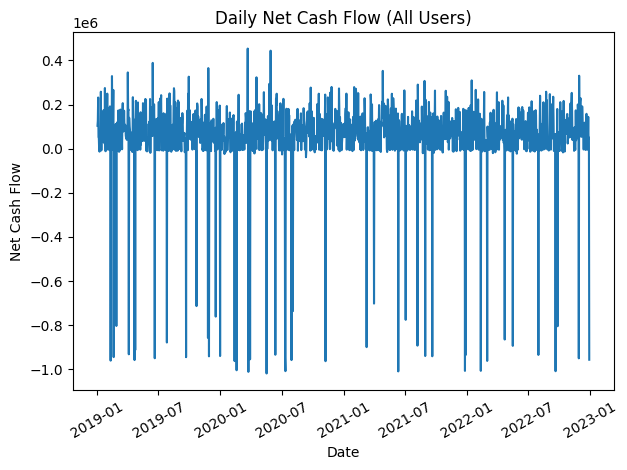

In [28]:
daily = (
    tx_clean.assign(signed_amount=lambda d: np.where(d["direction"]=="Expense", -d["amount"], d["amount"]))
    .groupby("date", as_index=False)["signed_amount"].sum()
    .sort_values("date")
)

plt.figure()
plt.plot(daily["date"], daily["signed_amount"])
plt.title("Daily Net Cash Flow (All Users)")
plt.xlabel("Date")
plt.ylabel("Net Cash Flow")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / "daily_net_cashflow_all_users.png", dpi=150)
plt.show()

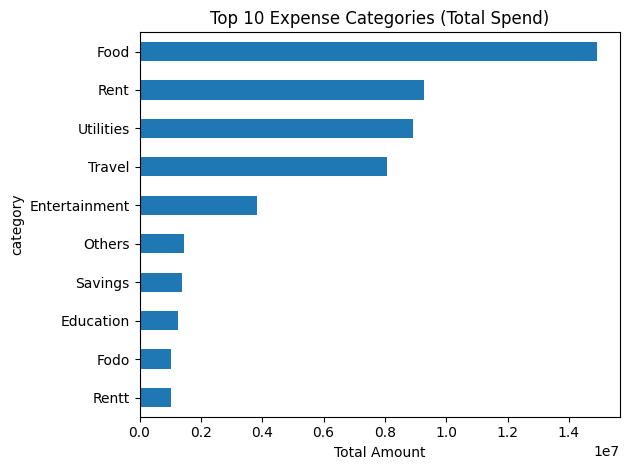

In [29]:
expenses = tx_clean[tx_clean["direction"]=="Expense"]

top_cat = (
    expenses.groupby("category")["amount"].sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
top_cat.sort_values().plot(kind="barh")
plt.title("Top 10 Expense Categories (Total Spend)")
plt.xlabel("Total Amount")
plt.tight_layout()
plt.savefig(FIG_DIR / "top10_expense_categories.png", dpi=150)
plt.show()

In [30]:
dfc = df_clean.copy()
dfc["date_parsed"] = parse_date_strict(dfc["date"])
dfc["amount_num"] = dfc["amount"].apply(clean_amount)
dfc["transaction_type_norm"] = dfc["transaction_type"].apply(normalize_transaction_type)
dfc["category_norm"] = dfc["category"].apply(normalize_text).str.title()
dfc["payment_mode_norm"] = dfc["payment_mode"].apply(normalize_payment_mode)

print("CLEAN date fail rate:", dfc["date_parsed"].isna().mean())
print("CLEAN amount fail rate:", dfc["amount_num"].isna().mean())
print("CLEAN payment_mode unique:", dfc["payment_mode_norm"].nunique(dropna=True))
print("CLEAN category unique:", dfc["category_norm"].nunique(dropna=True))

CLEAN date fail rate: 0.030566037735849056
CLEAN amount fail rate: 0.01867924528301887
CLEAN payment_mode unique: 8
CLEAN category unique: 31


In [31]:
print("DIRTY date fail rate:", df["date_parsed"].isna().mean())
print("DIRTY amount fail rate:", df["amount_num"].isna().mean())
print("DIRTY payment_mode unique:", df["payment_mode_norm"].nunique(dropna=True))
print("DIRTY category unique:", df["category_norm"].nunique(dropna=True))

DIRTY date fail rate: 0.02175359233634912
DIRTY amount fail rate: 0.011309207025013306
DIRTY payment_mode unique: 61
DIRTY category unique: 211


In [32]:
dq = pd.DataFrame({
    "dataset": ["CLEAN", "DIRTY (post-clean)"],
    "rows": [len(dfc), len(df)],
    "date_fail_rate": [dfc["date_parsed"].isna().mean(), df["date_parsed"].isna().mean()],
    "amount_fail_rate": [dfc["amount_num"].isna().mean(), df["amount_num"].isna().mean()],
    "payment_mode_unique": [dfc["payment_mode_norm"].nunique(dropna=True), df["payment_mode_norm"].nunique(dropna=True)],
    "category_unique": [dfc["category_norm"].nunique(dropna=True), df["category_norm"].nunique(dropna=True)],
})
dq

,dataset,rows,date_fail_rate,amount_fail_rate,payment_mode_unique,category_unique
0,CLEAN,15900,0.030566,0.018679,8,31
1,DIRTY (post-clean),15032,0.021754,0.011309,61,211
